# Notebook 4 — Toy distance ladder and a simple estimate of $H_0$

In this notebook, we build a simplified distance ladder in order to estimate the Hubble constant $H_0$.

The goal is not to reproduce a professional SH0ES analysis. Instead, we construct a pedagogical toy model that shows the logic of the local distance ladder:

1. calibrate the luminosity of nearby distance indicators,
2. use them to calibrate Type Ia supernovae,
3. use farther Type Ia supernovae to measure the local expansion rate.

At low redshift, we use the approximation

$$
v \approx cz \approx H_0 d.
$$

This approximation is only valid in the local Universe. It is sufficient here because the goal is to understand the structure of the inference.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize

# We will use emcee later in the notebook
import emcee
import corner

plt.style.use("default")

In [2]:
c_km_s = 299792.458  # speed of light in km/s

np.random.seed(42)          # reproducible emcee proposals
rng = np.random.default_rng(42)  # reproducible simulated data

H0_true = 72.0        # hidden true value, km/s/Mpc
M_SN_true = -19.3     # hidden true absolute magnitude of Type Ia supernovae

## 1. Magnitudes and distance modulus

Astronomers often express brightness using magnitudes.

- $m$ is the apparent magnitude: how bright the object appears from Earth.
- $M$ is the absolute magnitude: how bright the object would appear at 10 pc.
- $\mu = m - M$ is the distance modulus.

The distance modulus is related to the distance by

$$
\mu = 5\log_{10}(d_{\rm pc}) - 5.
$$

Therefore,

$$
d_{\rm pc} = 10^{(\mu+5)/5}.
$$

In this notebook, this formula is the bridge between observed magnitudes and physical distances.

In [3]:
def distance_modulus(m, M):
    return m - M

In [4]:
def distance_pc_from_mu(mu):
    #Convert distance modulus to distance in parsecs.
    return 10 ** ((mu + 5) / 5)

In [5]:
def distance_mpc_from_mu(mu):
    #Convert distance modulus to distance in megaparsecs.
    d_pc = distance_pc_from_mu(mu)
    return d_pc / 1e6

In [6]:
def velocity_from_redshift(z):
    return c_km_s * z   #Low-redshift approximation v = c z (km/s)

In [7]:
def mu_from_distance_mpc(d_Mpc):
    d_pc = d_Mpc * 1e6
    return 5 * np.log10(d_pc) - 5   #Convert distance in Mpc to distance modulus

In [8]:
m_test = 15.5
M_test = -19.3

mu_test = distance_modulus(m_test, M_test)
d_test = distance_mpc_from_mu(mu_test)

print("mu =", mu_test)
print("d_Mpc =", d_test)

z_test = 0.02
v_test = velocity_from_redshift(z_test)

print("v =", v_test, "km/s")

mu = 34.8
d_Mpc = 91.20108393559077
v = 5995.84916 km/s


## 2. Toy Cepheid calibration

Cepheids are variable stars whose pulsation period is related to their intrinsic luminosity.

In a simplified form, the period-luminosity relation can be written as

$$
M_{\rm Cepheid} = a\log_{10}(P) + b.
$$

If we measure the period $P$, we can estimate the absolute magnitude $M_{\rm Cepheid}$. Comparing this to the observed apparent magnitude $m_{\rm Cepheid}$ gives the distance modulus of the host galaxy.

In a real SH0ES-like analysis, this step requires careful calibration using geometric anchors such as Gaia parallaxes, the LMC, or NGC 4258. Here we use a simplified toy version.

## 3. Calibrating Type Ia supernovae

Type Ia supernovae are much brighter than Cepheids, so they can be observed at much larger distances.

However, to use them as distance indicators, we need to calibrate their absolute magnitude $M_{\rm SN}$.

If a nearby host galaxy contains both Cepheids and a Type Ia supernova, then the Cepheids provide the distance modulus of the host galaxy, $\mu_{\rm host}$.

The observed apparent magnitude of the supernova in that galaxy is $m_{\rm SN,host}$. Therefore, the calibrated absolute magnitude of the supernova is

$$
M_{\rm SN} = m_{\rm SN,host} - \mu_{\rm host}
$$

This is the key link between Cepheids and farther Type Ia supernovae.

### 3.1 Toy Cepheid-based calibration of $M_{\rm SN}$

In the first one-parameter models below, $M_{\rm SN}$ is temporarily fixed
to a noisy calibrated estimate. In the final two-parameter model, its
calibration uncertainty is propagated into the inference of $H_0$.

In a real distance-ladder analysis, the Cepheid-host calibration is modelled in much greater detail. In a real distance-ladder analysis, the Cepheid-host calibration is modelled in much greater detail.

In this toy model, we do not simulate individual Cepheids. Instead, we assume that Cepheids provide an observed distance modulus for a nearby host galaxy:

$$
\mu_{\rm host,obs} \pm \sigma_{\mu,\rm host}.
$$

A Type Ia supernova is observed in the same host galaxy with apparent magnitude

$$
m_{\rm SN,host,obs} \pm \sigma_{m,\rm SN}.
$$

The calibrated absolute magnitude is then

$$
M_{\rm SN,calib} = m_{\rm SN,host,obs} - \mu_{\rm host,obs}.
$$

Assuming that the two measurement uncertainties are independent, the calibration uncertainty is

$$
\sigma_{M_{\rm SN}} = \sqrt{\sigma_{m,\rm SN}^2 + \sigma_{\mu,\rm host}^2}.
$$

This toy calibration will later be used as a Gaussian constraint on $M_{\rm SN}$.

In [9]:
mu_host_true = 31.5          # true distance modulus of the nearby Cepheid host
sigma_mu_host = 0.08         # uncertainty from the toy Cepheid calibration

sigma_m_SN_host = 0.10       # apparent magnitude uncertainty of the calibrator SN

m_SN_host_true = M_SN_true + mu_host_true

mu_host_obs = rng.normal(mu_host_true, sigma_mu_host)
m_SN_host_obs = rng.normal(m_SN_host_true, sigma_m_SN_host)

M_SN_calibrated = m_SN_host_obs - mu_host_obs
sigma_M_SN_calibrated = np.sqrt(sigma_m_SN_host**2 + sigma_mu_host**2)

print(f"M_SN_true       = {M_SN_true:.3f}")
print(f"M_SN_calibrated = {M_SN_calibrated:.3f} ± {sigma_M_SN_calibrated:.3f}")

M_SN_true       = -19.300
M_SN_calibrated = -19.428 ± 0.128


## 4. Hubble-flow supernovae

Once $M_{\rm SN}$ is calibrated, we can use farther Type Ia supernovae to estimate distances.

For each Hubble-flow supernova, we measure:

- its apparent magnitude $m_i$,
- its redshift $z_i$.

Using the calibrated $M_{\rm SN}$, we compute

$$
\mu_i = m_i - M_{\rm SN}.
$$

Then we convert the distance modulus into a distance:

$$
d_{i,\rm Mpc}
=
10^{(\mu_i-25)/5}\ {\rm Mpc}.
$$

At low redshift, we approximate the recession velocity as

$$
v_i \approx cz_i.
$$

Finally, we estimate $H_0$ from

$$
v_i \approx H_0 d_i.
$$

### Simulating toy Hubble-flow supernovae

We now simulate a small sample of Type Ia supernovae in the local Hubble flow.

We choose hidden true values:

$$
H_0^{\rm true} = 72 \ \mathrm{km\,s^{-1}\,Mpc^{-1}}
$$

and

$$
M_{\rm SN}^{\rm true} = -19.3.
$$

For each simulated supernova, we generate a redshift $z_i$, compute the recession velocity using

$$
v_i = cz_i,
$$

and infer the true distance from

$$
d_i = \frac{v_i}{H_0^{\rm true}}.
$$

We then convert this distance into a distance modulus and an apparent magnitude. Finally, we add Gaussian observational noise to the apparent magnitude.

In [10]:
n_sn = 30             # number of simulated Hubble-flow supernovae
sigma_m_SN = 0.10     # magnitude uncertainty

z = rng.uniform(0.01, 0.08, size=n_sn)
z = np.sort(z)  #to have the points in order

v_true = velocity_from_redshift(z)
d_true_Mpc = v_true / H0_true
mu_true = mu_from_distance_mpc(d_true_Mpc)
m_true = M_SN_true + mu_true

m_obs = rng.normal(loc=m_true, scale=sigma_m_SN)

In [11]:
sn_df = pd.DataFrame({
    "z": z,
    "v_true_km_s": v_true,
    "d_true_Mpc": d_true_Mpc,
    "mu_true": mu_true,
    "m_true": m_true,
    "m_obs": m_obs,
    "sigma_m": sigma_m_SN,
})

sn_df.head()

,z,v_true_km_s,d_true_Mpc,mu_true,m_true,m_obs,sigma_m
0,0.013066,3917.167283,54.405101,33.678198,14.378198,14.326974,0.1
1,0.014467,4337.159825,60.238331,33.899365,14.599365,14.517987,0.1
2,0.016592,4974.280683,69.087232,34.196989,14.896989,14.958587,0.1
3,0.018968,5686.449639,78.978467,34.487544,15.187544,15.300441,0.1
4,0.020800,6235.762405,86.607811,34.687785,15.387785,15.376391,0.1


In [12]:
sn_df.describe()

,z,v_true_km_s,d_true_Mpc,mu_true,m_true,m_obs,sigma_m
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,3.000000e+01
mean,0.050305,15081.079355,209.459435,36.342314,17.042314,17.041180,1.000000e-01
std,0.021246,6369.354206,88.463253,1.192575,1.192575,1.194941,2.823006e-17
min,0.013066,3917.167283,54.405101,33.678198,14.378198,14.326974,1.000000e-01
25%,0.035102,10523.188573,146.155397,35.823862,16.523862,16.591238,1.000000e-01
50%,0.056442,16920.883686,235.012273,36.854812,17.554812,17.609563,1.000000e-01
75%,0.066951,20071.437844,278.769970,37.225926,17.925926,17.887220,1.000000e-01
max,0.078294,23471.820181,325.997503,37.566071,18.266071,18.347092,1.000000e-01


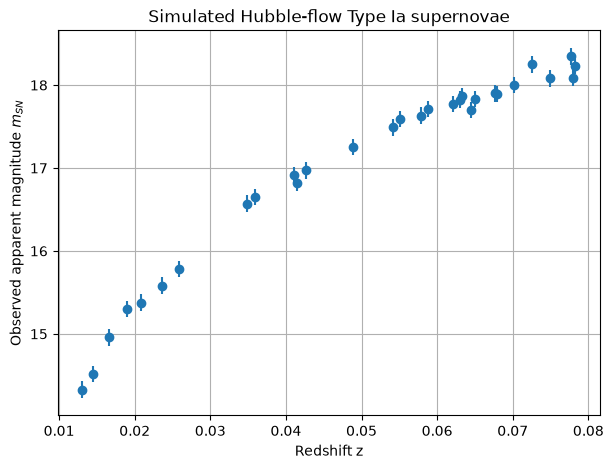

In [13]:
plt.figure(figsize=(7, 5))
plt.errorbar(sn_df["z"], sn_df["m_obs"], yerr=sn_df["sigma_m"], fmt="o")
plt.xlabel("Redshift z")
plt.ylabel("Observed apparent magnitude $m_{SN}$")
plt.title("Simulated Hubble-flow Type Ia supernovae")
plt.grid(True)
plt.show()

### Reconstructing observed distances

In the simulation, we know the true distances because we generated the data ourselves. In a real observation, however, we do not know the true distance.

We only observe the apparent magnitude $m_{\rm obs}$ and the redshift $z$.

Assuming that the Type Ia supernova absolute magnitude has been calibrated, we reconstruct the distance modulus using

$$
\mu_{\rm obs} = m_{\rm obs} - M_{\rm SN}.
$$

Then we convert $\mu_{\rm obs}$ into an observed distance $d_{\rm obs}$.

These reconstructed distances will be used to estimate $H_0$.

In [14]:
sn_df["mu_obs"] = distance_modulus(sn_df["m_obs"], M_SN_calibrated)
sn_df["d_obs_Mpc"] = distance_mpc_from_mu(sn_df["mu_obs"])
sn_df["v_obs_km_s"] = velocity_from_redshift(sn_df["z"])

sn_df[["z", "m_obs", "mu_obs", "d_obs_Mpc"]]

,z,m_obs,mu_obs,d_obs_Mpc
0,0.013066,14.326974,33.755350,56.372841
1,0.014467,14.517987,33.946363,61.556317
2,0.016592,14.958587,34.386963,75.403679
3,0.018968,15.300441,34.728817,88.259874
4,0.020800,15.376391,34.804766,91.401489
5,0.023625,15.580258,35.008634,100.398381
6,0.025907,15.782054,35.210430,110.175749
7,0.034817,16.571446,35.999821,158.476289
8,0.035956,16.650615,36.078991,164.360762
9,0.041039,16.917740,36.346116,185.875929


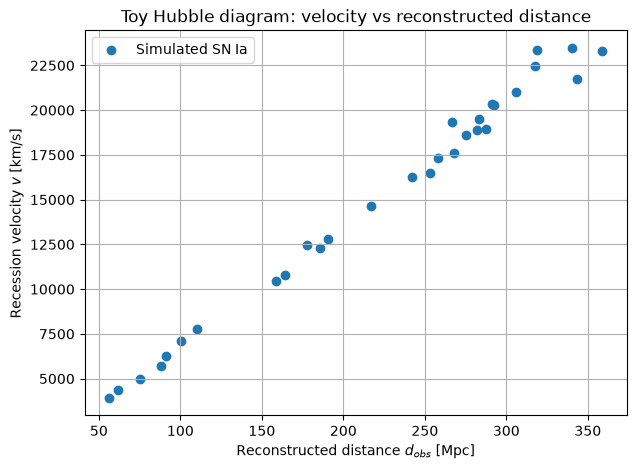

In [15]:
plt.figure(figsize=(7, 5))
plt.scatter(sn_df["d_obs_Mpc"], sn_df["v_obs_km_s"], label="Simulated SN Ia")
plt.xlabel("Reconstructed distance $d_{obs}$ [Mpc]")
plt.ylabel("Recession velocity $v$ [km/s]")
plt.title("Toy Hubble diagram: velocity vs reconstructed distance")
plt.grid(True)
plt.legend()
plt.show()

## 5. Frequentist estimate of $H_0$

As a first estimate, we fit the relation

$$
v_i = H_0 d_i.
$$

This is mathematically a linear fit through the origin, where the slope is $H_0$.

We define the residuals as

$$
r_i = v_i - H_0 d_i.
$$

Assuming Gaussian uncertainties, we define

$$
\chi^2(H_0) = \sum_i \left(\frac{r_i}{\sigma_{v,i}}\right)^2.
$$

The best-fit value of $H_0$ is the value that minimizes $\chi^2$.

### Fitting the local Hubble law

We now fit the local Hubble law

$$
v_i = H_0 d_i.
$$

Here, $H_0$ is the only free parameter. It is the slope of the relation between recession velocity and distance.

We use the reconstructed distances $d_{\rm obs}$ and the recession velocities $v = cz$.

This first velocity-distance fit is deliberately naive. The simulated
observational noise was added in magnitude space, whereas the fit below assigns
a toy velocity uncertainty of $300\ {\rm km\,s^{-1}}$ and ignores uncertainty
in the reconstructed distances.

Its uncertainty on $H_0$ is therefore only illustrative. The magnitude-space
likelihood introduced below is statistically more consistent with the way the
data were generated.

In [16]:
def model_velocity_from_H0(H0, d_Mpc):
    return H0 * d_Mpc

def chi2_H0(H0, d_Mpc, v_km_s, sigma_v):
    v_model = model_velocity_from_H0(H0, d_Mpc)
    residuals = v_km_s - v_model
    return np.sum((residuals / sigma_v) ** 2)

def neg_log_likelihood_H0(theta, d_Mpc, v_km_s, sigma_v):
    H0 = theta[0]
    chi2 = chi2_H0(H0, d_Mpc, v_km_s, sigma_v)
    return 0.5 * chi2

In [17]:
sigma_v = 300.0  # km/s, toy peculiar velocity uncertainty
sn_df["sigma_v"] = sigma_v

In [18]:
initial_guess = np.array([70.0])

result = minimize(
    neg_log_likelihood_H0,
    initial_guess,
    args=(sn_df["d_obs_Mpc"], sn_df["v_obs_km_s"], sn_df["sigma_v"]),
)

H0_best = result.x[0]
print(H0_best)

67.91004510572827


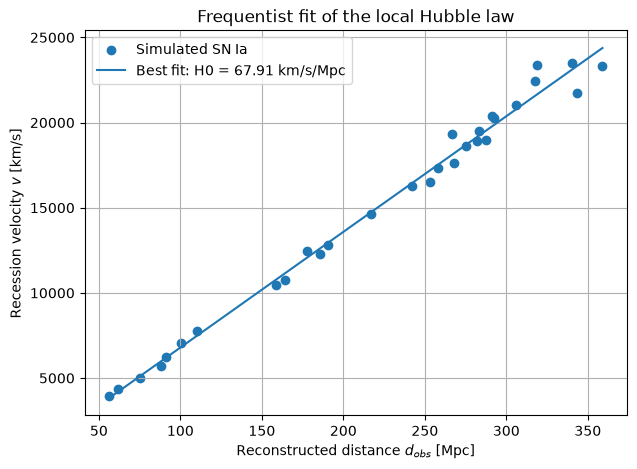

In [19]:
d_grid = np.linspace(sn_df["d_obs_Mpc"].min(), sn_df["d_obs_Mpc"].max(), 200)   # to draw the best fit line
v_best = model_velocity_from_H0(H0_best, d_grid)

plt.figure(figsize=(7, 5))
plt.scatter(sn_df["d_obs_Mpc"], sn_df["v_obs_km_s"], label="Simulated SN Ia")
plt.plot(d_grid, v_best, label=f"Best fit: H0 = {H0_best:.2f} km/s/Mpc")
plt.xlabel("Reconstructed distance $d_{obs}$ [Mpc]")
plt.ylabel("Recession velocity $v$ [km/s]")
plt.title("Frequentist fit of the local Hubble law")
plt.grid(True)
plt.legend()
plt.show()

## 6. Bayesian estimate of $H_0$ with `emcee`

We now estimate $H_0$ using the same Bayesian logic as in the previous notebook.

The parameter vector is

$$
\theta = (H_0).
$$

We choose a broad uniform prior:

$$
50 < H_0 < 90.
$$

The likelihood is Gaussian:

$$
\log L(H_0) = -\frac{1}{2}\chi^2(H_0).
$$

The posterior is

$$
\log p(H_0|\mathrm{data}) = \log p(H_0) + \log L(H_0).
$$

We use `emcee` to sample this posterior distribution.

In [20]:
def log_prior_H0(theta):
    H0 = theta[0]

    if 50.0 < H0 < 90.0:
        return 0.0
    return -np.inf


def log_likelihood_H0(theta, d_Mpc, v_km_s, sigma_v):
    H0 = theta[0]
    chi2 = chi2_H0(H0, d_Mpc, v_km_s, sigma_v)
    return -0.5 * chi2


def log_posterior_H0(theta, d_Mpc, v_km_s, sigma_v):
    lp = log_prior_H0(theta)

    if not np.isfinite(lp):
        return -np.inf

    return lp + log_likelihood_H0(theta, d_Mpc, v_km_s, sigma_v)

In [21]:
ndim = 1
nwalkers = 32
nsteps = 3000

initial_pos = H0_best + 1e-2 * rng.normal(size=(nwalkers, ndim))

sampler = emcee.EnsembleSampler(
    nwalkers,
    ndim,
    log_posterior_H0,
    args=(sn_df["d_obs_Mpc"], sn_df["v_obs_km_s"], sn_df["sigma_v"]),
)

sampler.run_mcmc(initial_pos, nsteps, progress=True);

100%|██████████| 3000/3000 [00:19<00:00, 153.29it/s]


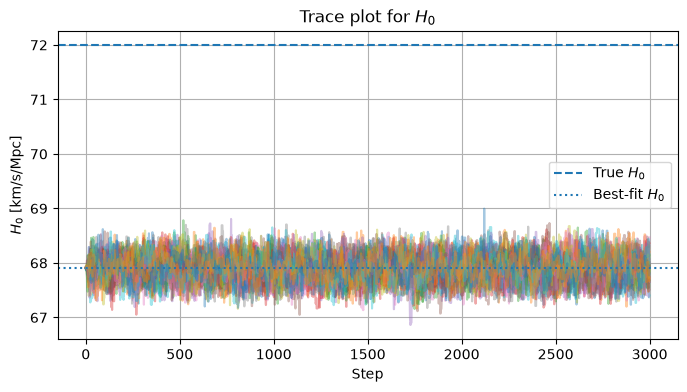

In [22]:
samples = sampler.get_chain()

plt.figure(figsize=(8, 4))

for walker in range(nwalkers):
    plt.plot(samples[:, walker, 0], alpha=0.4)

plt.axhline(H0_true, linestyle="--", label="True $H_0$")
plt.axhline(H0_best, linestyle=":", label="Best-fit $H_0$")

plt.xlabel("Step")
plt.ylabel("$H_0$ [km/s/Mpc]")
plt.title("Trace plot for $H_0$")
plt.grid(True)
plt.legend()
plt.show()

In [23]:
flat_samples = sampler.get_chain(discard=500, flat=True)

print(flat_samples.shape)

H0_samples = flat_samples[:, 0]

H0_median = np.percentile(H0_samples, 50)
H0_lower = np.percentile(H0_samples, 16)
H0_upper = np.percentile(H0_samples, 84)

H0_minus = H0_median - H0_lower
H0_plus = H0_upper - H0_median

print(f"H0 = {H0_median:.2f} +{H0_plus:.2f} -{H0_minus:.2f} km/s/Mpc")

(80000, 1)
H0 = 67.90 +0.23 -0.23 km/s/Mpc


The one-parameter model samples around $H_0 \approx 68$ instead of the hidden true value $H_0=72$ because $M_{\rm SN}$ is fixed to the noisy calibrated value, not to the true value. In this simulation, the calibration gives a more negative $M_{\rm SN}$, meaning that supernovae are inferred to be intrinsically brighter. This increases inferred distances and therefore lowers the inferred value of $H_0$.

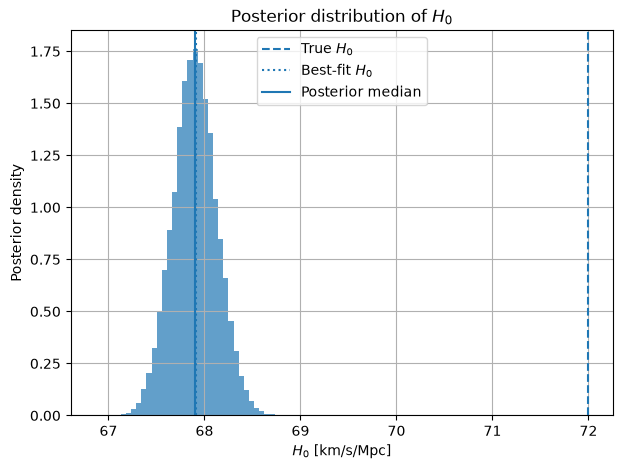

In [24]:
plt.figure(figsize=(7, 5))

plt.hist(H0_samples, bins=40, density=True, alpha=0.7)
plt.axvline(H0_true, linestyle="--", label="True $H_0$")
plt.axvline(H0_best, linestyle=":", label="Best-fit $H_0$")
plt.axvline(H0_median, linestyle="-", label="Posterior median")

plt.xlabel("$H_0$ [km/s/Mpc]")
plt.ylabel("Posterior density")
plt.title("Posterior distribution of $H_0$")
plt.grid(True)
plt.legend()
plt.show()

### 6.1 Magnitude-space likelihood with fixed $M_{\rm SN}$

The previous fit used reconstructed distances and fitted the relation $v = H_0 d$.

However, in this toy simulation the observational noise was added to the apparent magnitudes. Therefore, a more consistent approach is to compare the observed magnitudes directly to model-predicted magnitudes.

For a given value of $H_0$, the low-redshift distance model is

$$
d_{\rm model}(z;H_0) = \frac{cz}{H_0}.
$$

We then compute the model distance modulus

$$
\mu_{\rm model} = 5\log_{10}(d_{\rm model,pc}) - 5,
$$

and the model apparent magnitude

$$
m_{\rm model} = M_{\rm SN} + \mu_{\rm model}.
$$

The chi-square is then

$$
\chi^2(H_0) = \sum_i \left(\frac{m_{\rm obs,i} - m_{\rm model,i}(H_0)}{\sigma_{m,i}}\right)^2.
$$

This likelihood is more consistent with the way the simulated data were generated.

In [25]:
def model_magnitude_from_H0(H0, z, M_SN):
    """
    Predict apparent magnitude from redshift and H0
    using the low-redshift approximation d = cz / H0.
    """
    v_km_s = velocity_from_redshift(z)
    d_Mpc = v_km_s / H0
    mu_model = mu_from_distance_mpc(d_Mpc)
    m_model = M_SN + mu_model
    return m_model

In [26]:
def chi2_H0_magnitude(H0, z, m_obs, sigma_m, M_SN):
    """
    Chi-square in magnitude space.
    """
    m_model = model_magnitude_from_H0(H0, z, M_SN)
    residuals = m_obs - m_model
    return np.sum((residuals / sigma_m) ** 2)

In [27]:
def neg_log_likelihood_H0_magnitude(theta, z, m_obs, sigma_m, M_SN):
    H0 = theta[0]
    chi2 = chi2_H0_magnitude(H0, z, m_obs, sigma_m, M_SN)
    return 0.5 * chi2

In [28]:
initial_guess = np.array([70.0])

result_mag = minimize(
    neg_log_likelihood_H0_magnitude,
    initial_guess,
    args=(sn_df["z"], sn_df["m_obs"], sn_df["sigma_m"], M_SN_calibrated),
)

H0_best_mag = result_mag.x[0]
H0_best_mag

np.float64(67.90225040870143)

In [29]:
def log_likelihood_H0_magnitude(theta, z, m_obs, sigma_m, M_SN):
    H0 = theta[0]
    chi2 = chi2_H0_magnitude(H0, z, m_obs, sigma_m, M_SN)
    return -0.5 * chi2


def log_posterior_H0_magnitude(theta, z, m_obs, sigma_m, M_SN):
    lp = log_prior_H0(theta)

    if not np.isfinite(lp):
        return -np.inf

    return lp + log_likelihood_H0_magnitude(theta, z, m_obs, sigma_m, M_SN)

In [30]:
ndim = 1
nwalkers = 32
nsteps = 3000

initial_pos_mag = H0_best_mag + 1e-2 * rng.normal(size=(nwalkers, ndim))

sampler_mag = emcee.EnsembleSampler(
    nwalkers,
    ndim,
    log_posterior_H0_magnitude,
    args=(sn_df["z"], sn_df["m_obs"], sn_df["sigma_m"], M_SN_calibrated),
)

sampler_mag.run_mcmc(initial_pos_mag, nsteps, progress=True);

100%|██████████| 3000/3000 [00:38<00:00, 78.04it/s]


In [31]:
flat_samples_mag = sampler_mag.get_chain(discard=500, flat=True)

H0_samples_mag = flat_samples_mag[:, 0]

H0_median_mag = np.percentile(H0_samples_mag, 50)
H0_lower_mag = np.percentile(H0_samples_mag, 16)
H0_upper_mag = np.percentile(H0_samples_mag, 84)

H0_minus_mag = H0_median_mag - H0_lower_mag
H0_plus_mag = H0_upper_mag - H0_median_mag

print(flat_samples_mag.shape)
print(f"H0 = {H0_median_mag:.2f} +{H0_plus_mag:.2f} -{H0_minus_mag:.2f} km/s/Mpc")

(80000, 1)
H0 = 67.90 +0.57 -0.56 km/s/Mpc


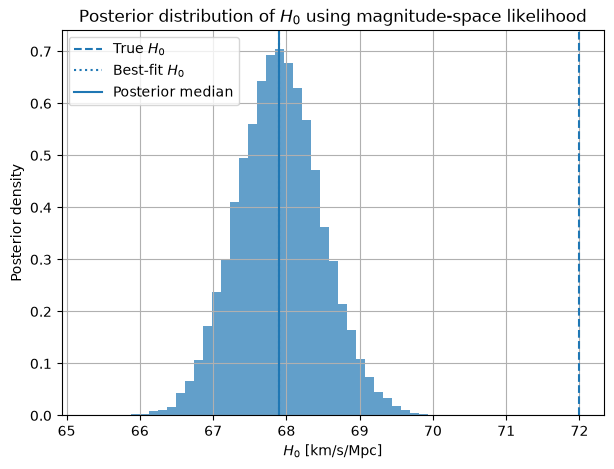

In [32]:
plt.figure(figsize=(7, 5))

plt.hist(H0_samples_mag, bins=40, density=True, alpha=0.7)
plt.axvline(H0_true, linestyle="--", label="True $H_0$")
plt.axvline(H0_best_mag, linestyle=":", label="Best-fit $H_0$")
plt.axvline(H0_median_mag, linestyle="-", label="Posterior median")

plt.xlabel("$H_0$ [km/s/Mpc]")
plt.ylabel("Posterior density")
plt.title("Posterior distribution of $H_0$ using magnitude-space likelihood")
plt.grid(True)
plt.legend()
plt.show()

### 6.2 Two-parameter distance-ladder model

In the previous Bayesian model, $M_{\rm SN}$ was fixed.

We now treat both $H_0$ and $M_{\rm SN}$ as unknown parameters:

$$
\theta = (H_0, M_{\rm SN}).
$$

The Hubble-flow supernovae constrain the combination of $H_0$ and $M_{\rm SN}$, while the toy Cepheid calibration provides an external Gaussian constraint on $M_{\rm SN}$.

The posterior is

$$
\log p(H_0, M_{\rm SN} | \mathrm{data})
=
\log p(H_0,M_{\rm SN})
+
\log L_{\rm calib}(M_{\rm SN})
+
\log L_{\rm SN}(H_0, M_{\rm SN}).
$$

This is a simplified Bayesian distance-ladder model.

In [33]:
def chi2_SN_two_params(theta, z, m_obs, sigma_m):
    H0, M_SN = theta
    m_model = model_magnitude_from_H0(H0, z, M_SN)
    residuals = m_obs - m_model
    return np.sum((residuals / sigma_m) ** 2)

def log_calibration_likelihood_M_SN(M_SN, M_SN_calibrated, sigma_M_SN_calibrated):
    return -0.5 * ((M_SN - M_SN_calibrated) / sigma_M_SN_calibrated) ** 2

def log_prior_two_params(theta):
    H0, M_SN = theta

    if 50.0 < H0 < 90.0 and -20.5 < M_SN < -18.0:
        return 0.0

    return -np.inf

def log_likelihood_two_params(theta, z, m_obs, sigma_m, M_SN_calibrated, sigma_M_SN_calibrated):
    H0, M_SN = theta
    chi2_SN = chi2_SN_two_params(theta, z, m_obs, sigma_m)
    loglike_SN = -0.5 * chi2_SN
    loglike_calib = log_calibration_likelihood_M_SN( M_SN, M_SN_calibrated, sigma_M_SN_calibrated)
    return loglike_SN + loglike_calib

def log_posterior_two_params( theta, z, m_obs, sigma_m, M_SN_calibrated, sigma_M_SN_calibrated):
    lp = log_prior_two_params(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_two_params(theta, z, m_obs, sigma_m, M_SN_calibrated, sigma_M_SN_calibrated)

In [34]:
ndim = 2
nwalkers = 32
nsteps = 4000

theta_start = np.array([H0_best_mag, M_SN_calibrated])

initial_pos_two = theta_start + np.array([0.1, 0.01]) * rng.normal(size=(nwalkers, ndim))

sampler_two = emcee.EnsembleSampler(
    nwalkers,
    ndim,
    log_posterior_two_params,
    args=(
        sn_df["z"],
        sn_df["m_obs"],
        sn_df["sigma_m"],
        M_SN_calibrated,
        sigma_M_SN_calibrated
    ),
)

sampler_two.run_mcmc(initial_pos_two, nsteps, progress=True);

100%|██████████| 4000/4000 [00:54<00:00, 73.51it/s]


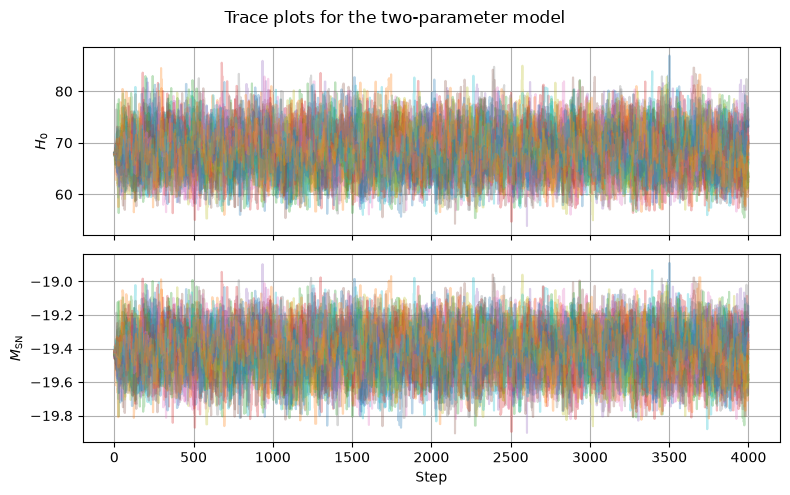

In [35]:
samples_two = sampler_two.get_chain()

labels = [r"$H_0$", r"$M_{\rm SN}$"]

fig, axes = plt.subplots(ndim, figsize=(8, 5), sharex=True)

for i in range(ndim):
    ax = axes[i]
    for walker in range(nwalkers):
        ax.plot(samples_two[:, walker, i], alpha=0.3)
    ax.set_ylabel(labels[i])
    ax.grid(True)

axes[-1].set_xlabel("Step")
fig.suptitle("Trace plots for the two-parameter model")
plt.tight_layout()
plt.show()

The two-parameter model allows $M_{\rm SN}$ to vary within its calibration uncertainty. As a result, the uncertainty on $H_0$ becomes larger, and the true value $H_0=72$ becomes compatible with the posterior. This shows how calibration uncertainty propagates into the final inference of the Hubble constant.

In [36]:
discard = 500

acceptance_two = np.mean(sampler_two.acceptance_fraction)
tau_two = sampler_two.get_autocorr_time(discard=discard)
ess_two = nwalkers * (nsteps - discard) / tau_two

print(f"Mean acceptance fraction: {acceptance_two:.3f}")
print("Autocorrelation times:", tau_two)
print("Effective sample sizes:", ess_two)

Mean acceptance fraction: 0.714
Autocorrelation times: [30.89472984 31.16763797]
Effective sample sizes: [3625.21376846 3593.47089832]


After discarding 500 steps, each walker retains 3,500 steps, corresponding to approximately 112–113 autocorrelation times. The combined chains yield about 3,600 effective samples for each parameter. Together with the stable trace plots, these diagnostics indicate adequate sampling for this two-parameter toy model. The mean acceptance fraction is relatively high, but it does not indicate a sampling problem here.

In [37]:
flat_samples_two = sampler_two.get_chain(discard=discard, flat=True)

H0_samples_two = flat_samples_two[:, 0]
M_SN_samples_two = flat_samples_two[:, 1]

H0_median_two = np.percentile(H0_samples_two, 50)
H0_lower_two = np.percentile(H0_samples_two, 16)
H0_upper_two = np.percentile(H0_samples_two, 84)

M_SN_median_two = np.percentile(M_SN_samples_two, 50)
M_SN_lower_two = np.percentile(M_SN_samples_two, 16)
M_SN_upper_two = np.percentile(M_SN_samples_two, 84)

print(f"H0 = {H0_median_two:.2f} +{H0_upper_two - H0_median_two:.2f} -{H0_median_two - H0_lower_two:.2f} km/s/Mpc")
print(f"M_SN = {M_SN_median_two:.3f} +{M_SN_upper_two - M_SN_median_two:.3f} -{M_SN_median_two - M_SN_lower_two:.3f}")

H0 = 68.28 +4.11 -3.92 km/s/Mpc
M_SN = -19.417 +0.126 -0.128


### Interpretation of the two-parameter model

The two-parameter model treats both $H_0$ and $M_{\rm SN}$ as unknown parameters.

This is more realistic than the previous model, because the Type Ia supernova absolute magnitude is not known perfectly. It is calibrated using nearby Cepheid host galaxies and therefore has an uncertainty.

In this toy simulation, the Cepheid-based calibration gives a value of $M_{\rm SN}$ slightly different from the hidden true value. This shifts the inferred value of $H_0$.

The uncertainty on $H_0$ is larger than in the one-parameter model, because the uncertainty on $M_{\rm SN}$ is now propagated into the final inference.

This is the main lesson of the toy distance ladder: an uncertainty in the absolute calibration of standard candles directly affects the inferred value of $H_0$.

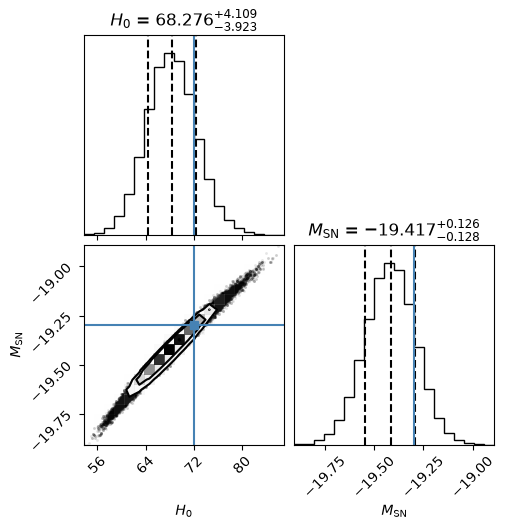

In [38]:
fig = corner.corner(
    flat_samples_two,
    labels=[r"$H_0$", r"$M_{\rm SN}$"],
    truths=[H0_true, M_SN_true],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt=".3f",
)

plt.show()

### Corner plot interpretation

The corner plot shows the joint posterior distribution of $H_0$ and $M_{\rm SN}$.

The diagonal panels show the marginalized posterior distributions of each parameter separately.

The off-diagonal panel shows the correlation between $H_0$ and $M_{\rm SN}$.

This correlation appears because the observed apparent magnitudes of Hubble-flow supernovae constrain a combination of distance and intrinsic luminosity. Changing $M_{\rm SN}$ changes the inferred distances, which changes the value of $H_0$ needed to fit the same redshifts.

## 7. Discussion and limitations

This notebook is a toy model. It captures the logic of the local distance ladder, but it ignores many effects that are important in real analyses.

We ignored:

1. dust extinction,
2. 2. color, stretch, and intrinsic-scatter modelling for Type Ia supernovae,
3. Cepheid metallicity,
4. crowding and blending,
5. covariance between measurements,
6. peculiar velocity corrections,
7. selection effects,
8. the full cosmological luminosity-distance relation.

Therefore, the numerical value obtained here should not be interpreted as a professional measurement of $H_0$. The goal is to understand how the inference works.

In [39]:
summary_df = pd.DataFrame({
    "model": [
        "Velocity-distance fit",
        "Magnitude-space fixed M_SN",
        "Two-parameter model",
    ],
    "H0_median_or_best": [
        H0_best,
        H0_median_mag,
        H0_median_two,
    ],
    "minus_error": [
        np.nan,
        H0_minus_mag,
        H0_median_two - H0_lower_two,
    ],
    "plus_error": [
        np.nan,
        H0_plus_mag,
        H0_upper_two - H0_median_two,
    ],
})

summary_df

,model,H0_median_or_best,minus_error,plus_error
0,Velocity-distance fit,67.910045,NaN,NaN
1,Magnitude-space fixed M_SN,67.897773,0.564439,0.568122
2,Two-parameter model,68.275927,3.922591,4.108572


### Main takeaway

This toy notebook shows how an uncertainty in the absolute calibration of Type Ia supernovae propagates into the inferred value of $H_0$.

When $M_{\rm SN}$ is fixed, the uncertainty on $H_0$ is artificially small. When $M_{\rm SN}$ is treated as an uncertain calibration parameter, the posterior uncertainty on $H_0$ increases.

This captures the central logic of the local distance ladder: Cepheids calibrate the absolute luminosity of Type Ia supernovae, and calibrated supernovae are then used to infer $H_0$ from the Hubble flow.